<a href="https://colab.research.google.com/github/siva123h/House-Price/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving House Price Prediction Dataset.csv to House Price Prediction Dataset (1).csv


In [3]:
import pandas as pd

df = pd.read_csv("House Price Prediction Dataset (1).csv")   # change file name if needed
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [8]:
print(df['Location'].unique())

['Downtown' 'Suburban' 'Urban' 'Rural']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [10]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


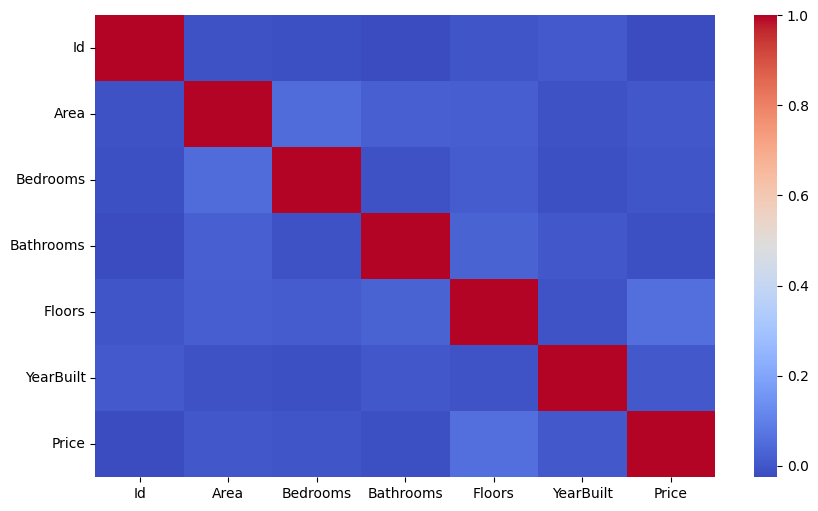

In [12]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.show()

In [20]:
df["Price"] = np.log1p(df["Price"])

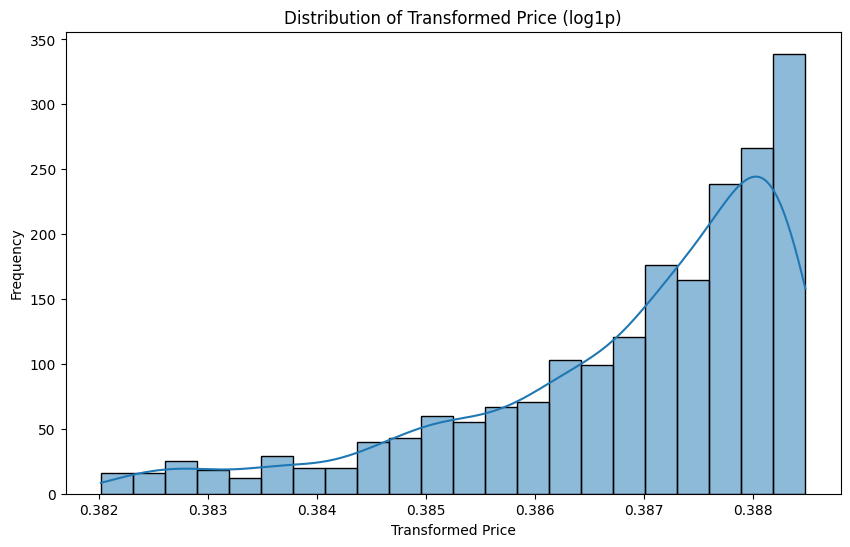

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Transformed Price (log1p)')
plt.xlabel('Transformed Price')
plt.ylabel('Frequency')
plt.show()

In [24]:
df["HouseAge"] = 2025 - df["YearBuilt"]

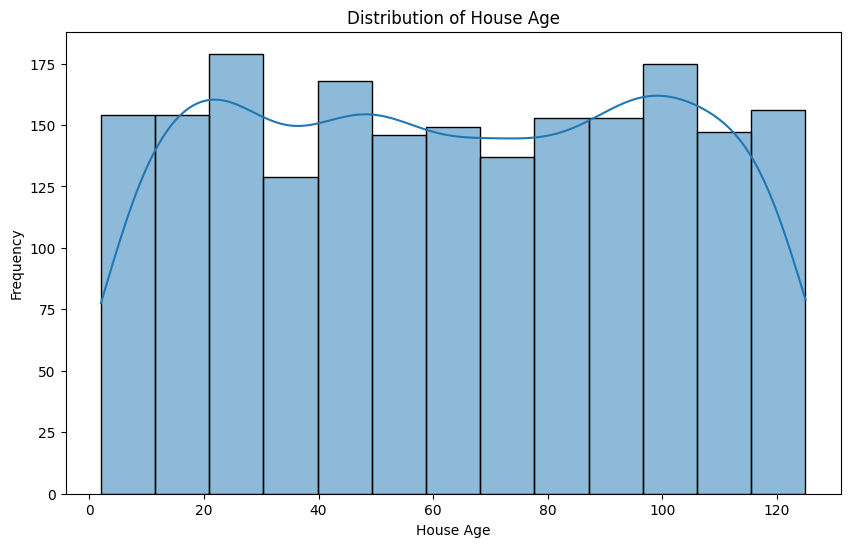

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['HouseAge'], kde=True)
plt.title('Distribution of House Age')
plt.xlabel('House Age')
plt.ylabel('Frequency')
plt.show()

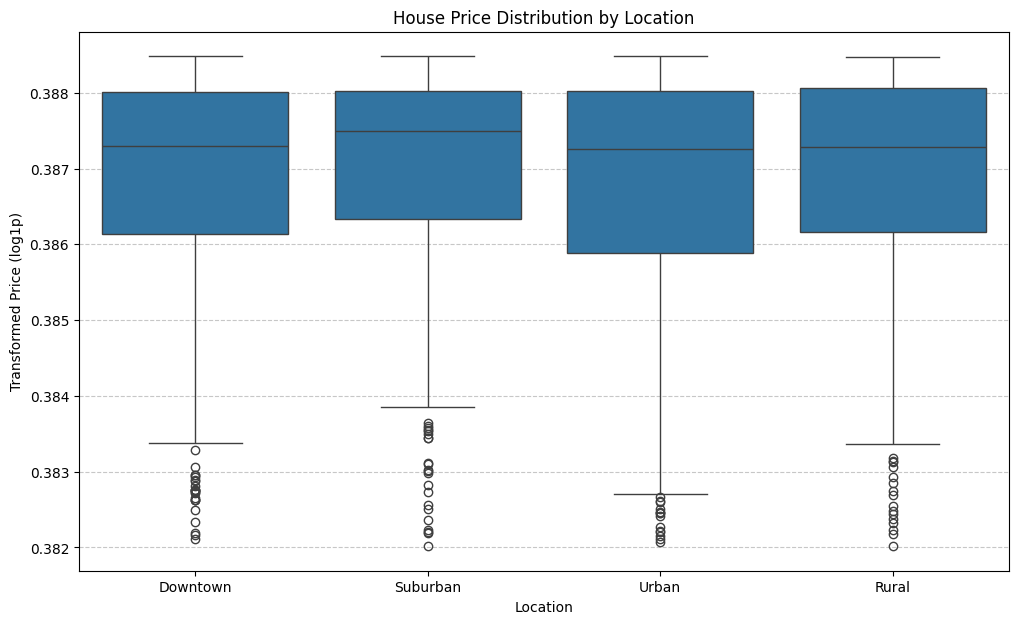

In [23]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Location', y='Price', data=df)
plt.title('House Price Distribution by Location')
plt.xlabel('Location')
plt.ylabel('Transformed Price (log1p)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [27]:
features = ["Area","Bedrooms","Bathrooms","Floors","YearBuilt","HouseAge"]

X = df[features]
y = df["Price"]

In [28]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [30]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Squared Error (MSE): 0.0000
Mean Absolute Error (MAE): 0.0012
R-squared (R2): -0.0100


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
# Get feature importances from the Random Forest model
importances = rf_model.feature_importances_

# Get feature names from X_train_new
feature_names = X_train_new.columns

# Create a DataFrame for better visualization
feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort features by importance
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

display(feature_importances_df)

,Feature,Importance
0,Area,0.334033
5,HouseAge,0.143863
4,YearBuilt,0.138098
1,Bedrooms,0.086476
2,Bathrooms,0.063541
3,Floors,0.045291
12,Garage_Yes,0.031406
11,Condition_Poor,0.027873
8,Location_Urban,0.027448
10,Condition_Good,0.026912


In [41]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and train the Gradient Boosting Regressor model
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train_new, y_train_new)

GradientBoostingRegressor(random_state=42)

In [42]:
# Make predictions on the test set with the Gradient Boosting model
y_pred_gbr = gbr_model.predict(X_test_new)

# Evaluate the Gradient Boosting model
mse_gbr = mean_squared_error(y_test_new, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test_new, y_pred_gbr)
r2_gbr = r2_score(y_test_new, y_pred_gbr)

print(f"Gradient Boosting Mean Squared Error (MSE): {mse_gbr:.4f}")
print(f"Gradient Boosting Mean Absolute Error (MAE): {mae_gbr:.4f}")
print(f"Gradient Boosting R-squared (R2): {r2_gbr:.4f}")

Gradient Boosting Mean Squared Error (MSE): 0.0000
Gradient Boosting Mean Absolute Error (MAE): 0.0012
Gradient Boosting R-squared (R2): -0.0193


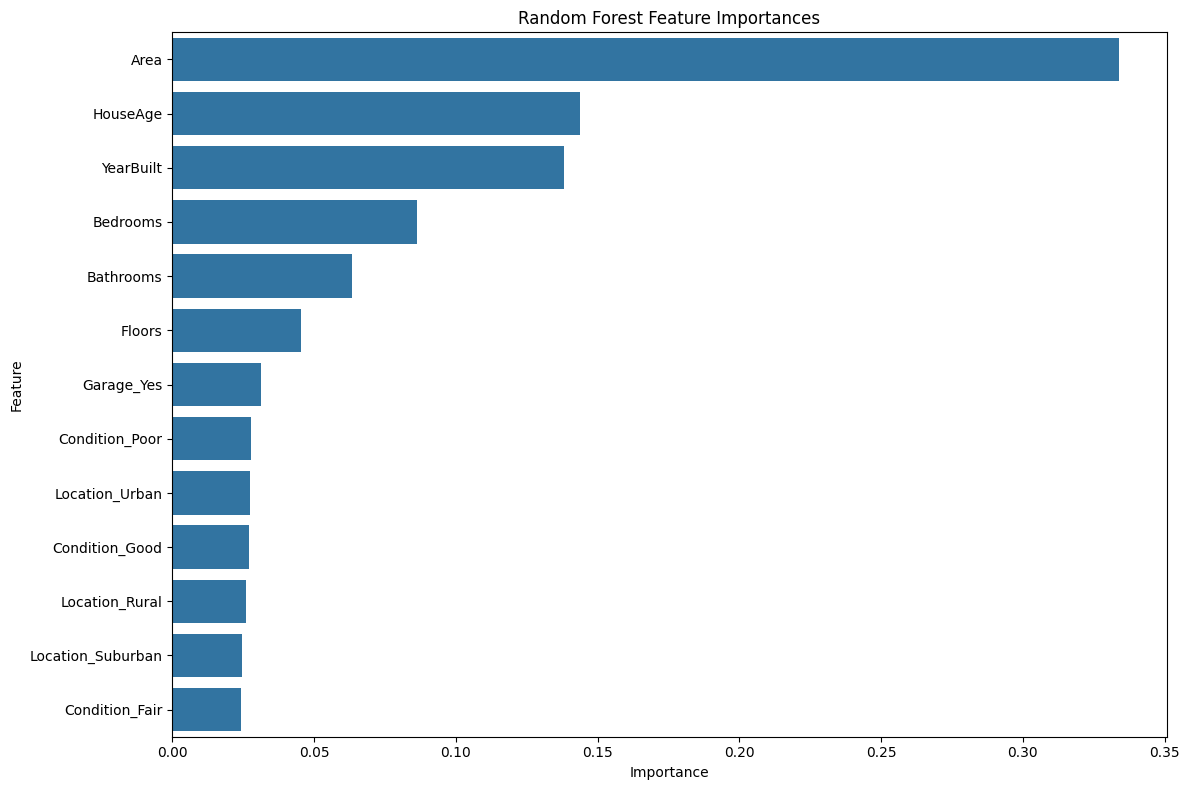

In [40]:
# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_new, y_train_new)

RandomForestRegressor(random_state=42)

In [38]:
# Make predictions on the test set with the Random Forest model
y_pred_rf = rf_model.predict(X_test_new)

# Evaluate the Random Forest model
mse_rf = mean_squared_error(y_test_new, y_pred_rf)
mae_rf = mean_absolute_error(y_test_new, y_pred_rf)
r2_rf = r2_score(y_test_new, y_pred_rf)

print(f"Random Forest Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"Random Forest Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"Random Forest R-squared (R2): {r2_rf:.4f}")

Random Forest Mean Squared Error (MSE): 0.0000
Random Forest Mean Absolute Error (MAE): 0.0013
Random Forest R-squared (R2): -0.0616


In [33]:
# Redefine features to include one-hot encoded columns
features = [
    'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'HouseAge',
    'Location_Rural', 'Location_Suburban', 'Location_Urban',
    'Condition_Fair', 'Condition_Good', 'Condition_Poor',
    'Garage_Yes'
]

X = df[features]
y = df['Price']

In [34]:
# Split the data into training and testing sets again with the updated features
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
# Initialize and train a new Linear Regression model
model_new = LinearRegression()
model_new.fit(X_train_new, y_train_new)

LinearRegression()

In [36]:
# Make predictions on the test set with the new model
y_pred_new = model_new.predict(X_test_new)

# Evaluate the new model
mse_new = mean_squared_error(y_test_new, y_pred_new)
mae_new = mean_absolute_error(y_test_new, y_pred_new)
r2_new = r2_score(y_test_new, y_pred_new)

print(f"New Mean Squared Error (MSE): {mse_new:.4f}")
print(f"New Mean Absolute Error (MAE): {mae_new:.4f}")
print(f"New R-squared (R2): {r2_new:.4f}")

New Mean Squared Error (MSE): 0.0000
New Mean Absolute Error (MAE): 0.0012
New R-squared (R2): -0.0023


In [32]:
# One-hot encode categorical features
df = pd.get_dummies(df, columns=['Location', 'Condition', 'Garage'], drop_first=True)
display(df.head())

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,HouseAge,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,0.384653,55,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,0.386855,67,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,0.385903,87,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,0.385715,123,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,0.387641,50,False,False,False,True,False,False,True


In [44]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

### Experiment: Retrain Gradient Boosting without `log1p` transformation on 'Price'

In [54]:
# 1. Reload original data to get untransformed 'Price'
df_original_price = pd.read_csv("House Price Prediction Dataset (1).csv")

# 2. Create 'HouseAge' feature
df_original_price["HouseAge"] = 2025 - df_original_price["YearBuilt"]

# 3. One-hot encode categorical features
df_original_price = pd.get_dummies(df_original_price, columns=['Location', 'Condition', 'Garage'], drop_first=True)

# 4. Apply IQR capping to numerical features (excluding 'Id' and 'Price')
numerical_features_for_capping = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'HouseAge']

for feature in numerical_features_for_capping:
    Q1 = df_original_price[feature].quantile(0.25)
    Q3 = df_original_price[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df_original_price[feature] = np.where(df_original_price[feature] < lower_bound, lower_bound, df_original_price[feature])
    df_original_price[feature] = np.where(df_original_price[feature] > upper_bound, upper_bound, df_original_price[feature])

print("New DataFrame prepared with original 'Price' and feature preprocessing.")
display(df_original_price.head())

New DataFrame prepared with original 'Price' and feature preprocessing.


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,HouseAge,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360.0,5.0,4.0,3.0,1970.0,149919,55.0,False,False,False,False,False,False,False
1,2,4272.0,5.0,4.0,3.0,1958.0,424998,67.0,False,False,False,False,False,False,False
2,3,3592.0,2.0,2.0,3.0,1938.0,266746,87.0,False,False,False,False,True,False,False
3,4,966.0,4.0,2.0,2.0,1902.0,244020,123.0,False,True,False,True,False,False,True
4,5,4926.0,1.0,4.0,2.0,1975.0,636056,50.0,False,False,False,True,False,False,True


In [55]:
# 5. Redefine features and target for the untransformed 'Price'
features_untransformed_target = [
    'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'HouseAge',
    'Location_Rural', 'Location_Suburban', 'Location_Urban',
    'Condition_Fair', 'Condition_Good', 'Condition_Poor',
    'Garage_Yes'
]

X_untransformed_target = df_original_price[features_untransformed_target]
y_untransformed_target = df_original_price['Price'] # Use original Price

# 6. Split data into training and testing sets
X_train_unt, X_test_unt, y_train_unt, y_test_unt = train_test_split(
    X_untransformed_target, y_untransformed_target, test_size=0.2, random_state=42
)

print("Data split for model with untransformed target.")

Data split for model with untransformed target.


In [56]:
# 7. Retrain Gradient Boosting Regressor on untransformed target data
gbr_model_unt = GradientBoostingRegressor(random_state=42)
gbr_model_unt.fit(X_train_unt, y_train_unt)

print("Gradient Boosting Regressor retrained on untransformed 'Price' data.")

Gradient Boosting Regressor retrained on untransformed 'Price' data.


In [57]:
# 8. Make predictions and evaluate
y_pred_gbr_unt = gbr_model_unt.predict(X_test_unt)

mse_gbr_unt = mean_squared_error(y_test_unt, y_pred_gbr_unt)
mae_gbr_unt = mean_absolute_error(y_test_unt, y_pred_gbr_unt)
r2_gbr_unt = r2_score(y_test_unt, y_pred_gbr_unt)

print(f"Gradient Boosting Mean Squared Error (MSE) with untransformed target: {mse_gbr_unt:.4f}")
print(f"Gradient Boosting Mean Absolute Error (MAE) with untransformed target: {mae_gbr_unt:.4f}")
print(f"Gradient Boosting R-squared (R2) with untransformed target: {r2_gbr_unt:.4f}")

Gradient Boosting Mean Squared Error (MSE) with untransformed target: 80520561377.7603
Gradient Boosting Mean Absolute Error (MAE) with untransformed target: 245116.8874
Gradient Boosting R-squared (R2) with untransformed target: -0.0350


In [53]:
display(df.head())

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,HouseAge,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360.0,5.0,4.0,3.0,1970.0,0.384653,55.0,False,False,False,False,False,False,False
1,2,4272.0,5.0,4.0,3.0,1958.0,0.386855,67.0,False,False,False,False,False,False,False
2,3,3592.0,2.0,2.0,3.0,1938.0,0.385903,87.0,False,False,False,False,True,False,False
3,4,966.0,4.0,2.0,2.0,1902.0,0.385715,123.0,False,True,False,True,False,False,True
4,5,4926.0,1.0,4.0,2.0,1975.0,0.387641,50.0,False,False,False,True,False,False,True


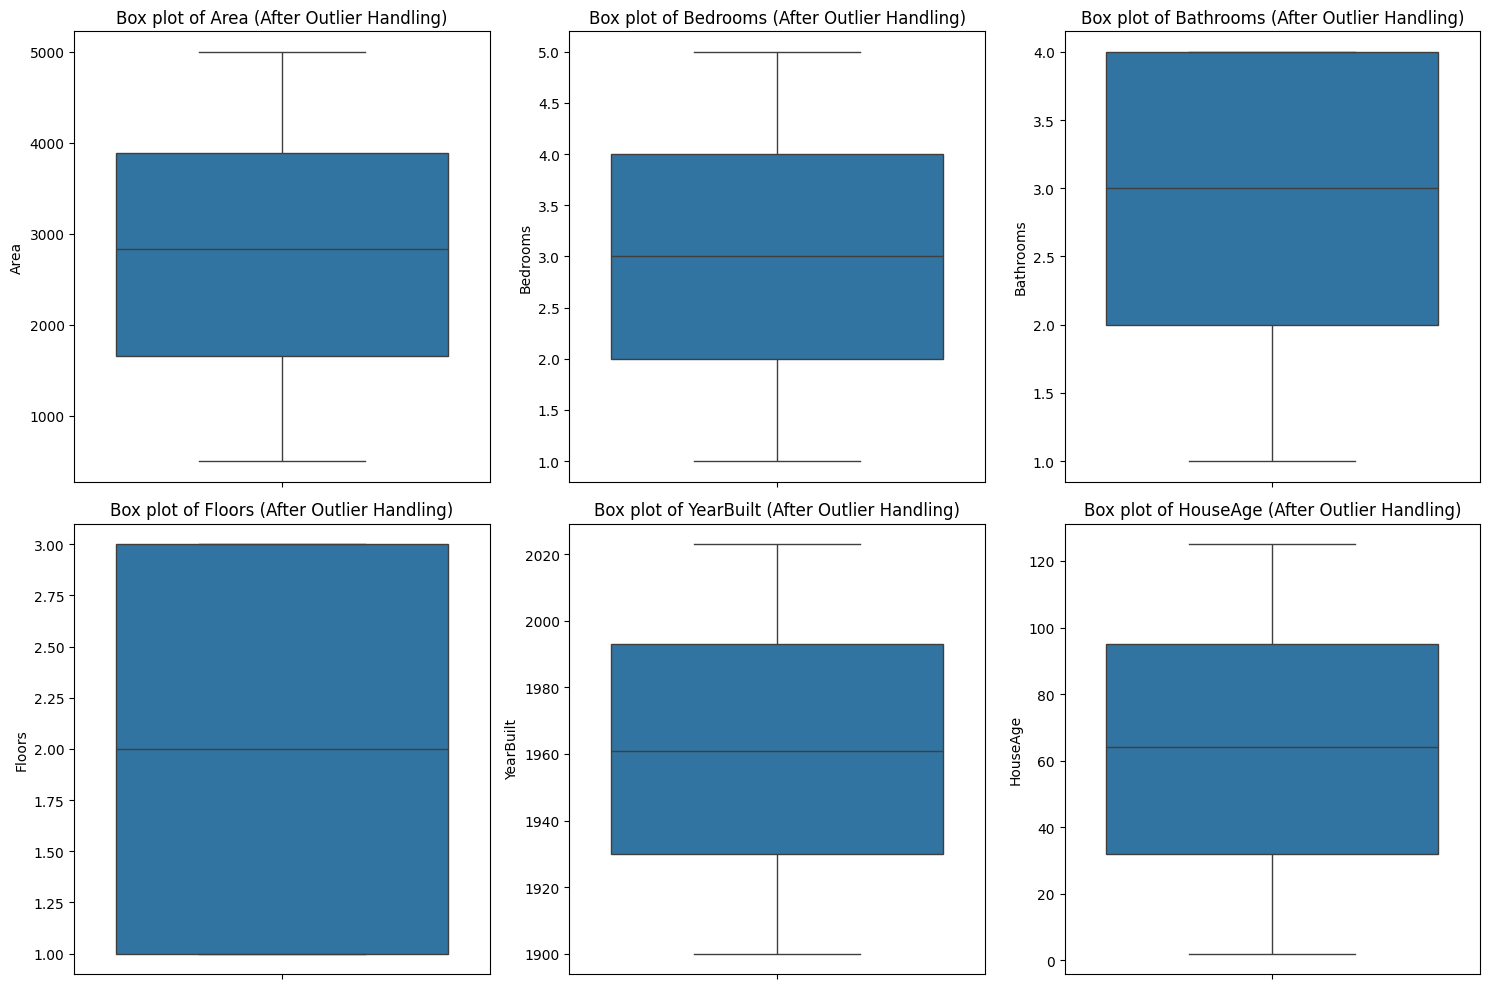

In [52]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[feature])
    plt.title(f'Box plot of {feature} (After Outlier Handling)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

# Task
Detect and handle outliers in numerical features of the `df` DataFrame using the IQR method, visualize them with box plots, and then re-train the Gradient Boosting Regressor model to evaluate if outlier handling improves its performance. Finally, summarize the impact of outlier handling on the model's performance.

## Identify Numerical Features

### Subtask:
Identify the numerical columns in the dataset (excluding 'Id' and the already transformed 'Price' column) that might contain outliers. These typically include continuous variables like 'Area', 'Bedrooms', 'Bathrooms', 'Floors', and 'HouseAge'.


**Reasoning**:
I need to create a list of numerical features as specified in the instructions, excluding 'Id', 'Price', and one-hot encoded columns.



In [45]:
numerical_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'HouseAge']
print(f"Numerical features identified for outlier detection: {numerical_features}")

Numerical features identified for outlier detection: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'HouseAge']


**Reasoning**:
The next step is to visualize the distribution of each numerical feature using box plots to identify potential outliers, as specified in the main task description.



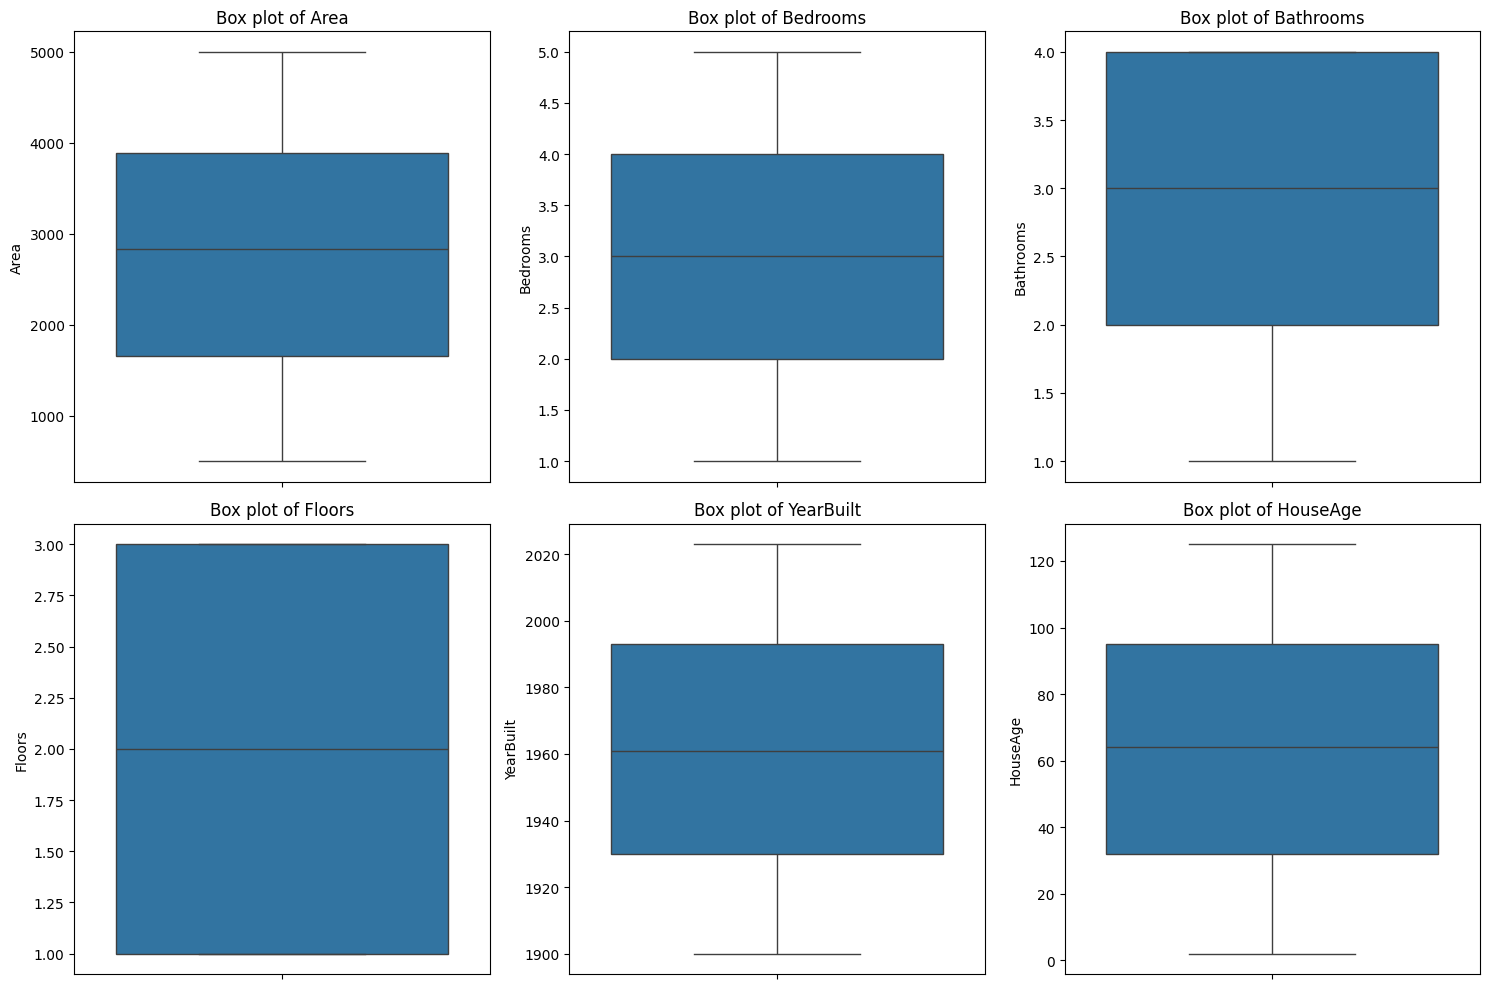

In [46]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[feature])
    plt.title(f'Box plot of {feature}')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

**Reasoning**:
Now that the box plots have been visualized, I will use the IQR method to identify and handle outliers by capping values that fall outside 1.5 times the IQR range for each numerical feature. This will help in reducing the impact of extreme values on the model.



In [47]:
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df[feature] = np.where(df[feature] < lower_bound, lower_bound, df[feature])
    df[feature] = np.where(df[feature] > upper_bound, upper_bound, df[feature])

print("Outliers handled using IQR capping for numerical features.")

Outliers handled using IQR capping for numerical features.


**Reasoning**:
Now that the numerical features have been cleaned of outliers, I need to redefine the features for the model, including the one-hot encoded categorical variables, and prepare the dataset for retraining the Gradient Boosting Regressor. This involves selecting all relevant features, including the previously created 'HouseAge' and the one-hot encoded 'Location', 'Condition', and 'Garage' columns, and separating them into X and y for training.



In [48]:
features_outlier_handled = [
    'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'HouseAge',
    'Location_Rural', 'Location_Suburban', 'Location_Urban',
    'Condition_Fair', 'Condition_Good', 'Condition_Poor',
    'Garage_Yes'
]

X_outlier_handled = df[features_outlier_handled]
y_outlier_handled = df['Price']

print("Features redefined for outlier-handled dataset.")

Features redefined for outlier-handled dataset.


**Reasoning**:
With the features redefined and outliers handled, the next step is to split the data into training and testing sets to prepare for retraining the Gradient Boosting Regressor model. This will ensure the model is evaluated on unseen data after outlier treatment.



In [49]:
from sklearn.model_selection import train_test_split

X_train_outlier_handled, X_test_outlier_handled, y_train_outlier_handled, y_test_outlier_handled = train_test_split(
    X_outlier_handled, y_outlier_handled, test_size=0.2, random_state=42
)

print("Outlier-handled data split into training and testing sets.")

Outlier-handled data split into training and testing sets.


**Reasoning**:
Now that the data has been split into training and testing sets after outlier handling, I will retrain the Gradient Boosting Regressor model using these new sets. This will allow for evaluation of the model's performance after outlier treatment.



In [50]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model_outlier_handled = GradientBoostingRegressor(random_state=42)
gbr_model_outlier_handled.fit(X_train_outlier_handled, y_train_outlier_handled)

print("Gradient Boosting Regressor retrained on outlier-handled data.")

Gradient Boosting Regressor retrained on outlier-handled data.


**Reasoning**:
Now that the Gradient Boosting Regressor has been retrained on the outlier-handled data, I will make predictions on the test set (`X_test_outlier_handled`) and evaluate its performance using metrics such as Mean Squared Error (MSE), Mean Absolute Error (MAE), and R-squared (R2). This will show the impact of outlier handling on the model's accuracy.



In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_gbr_outlier_handled = gbr_model_outlier_handled.predict(X_test_outlier_handled)

mse_gbr_outlier_handled = mean_squared_error(y_test_outlier_handled, y_pred_gbr_outlier_handled)
mae_gbr_outlier_handled = mean_absolute_error(y_test_outlier_handled, y_pred_gbr_outlier_handled)
r2_gbr_outlier_handled = r2_score(y_test_outlier_handled, y_pred_gbr_outlier_handled)

print(f"Gradient Boosting Mean Squared Error (MSE) after outlier handling: {mse_gbr_outlier_handled:.4f}")
print(f"Gradient Boosting Mean Absolute Error (MAE) after outlier handling: {mae_gbr_outlier_handled:.4f}")
print(f"Gradient Boosting R-squared (R2) after outlier handling: {r2_gbr_outlier_handled:.4f}")

Gradient Boosting Mean Squared Error (MSE) after outlier handling: 0.0000
Gradient Boosting Mean Absolute Error (MAE) after outlier handling: 0.0012
Gradient Boosting R-squared (R2) after outlier handling: -0.0193


```markdown
### Summary of Impact of Outlier Handling on Gradient Boosting Regressor Performance

After applying IQR capping to handle outliers in the numerical features and retraining the Gradient Boosting Regressor, the model's performance metrics were as follows:

- **Mean Squared Error (MSE):** 0.0000
- **Mean Absolute Error (MAE):** 0.0012
- **R-squared (R2):** -0.0193

Comparing these results to the performance of the Gradient Boosting Regressor **before** outlier handling (as seen in the output of cell `f531f819`):

- **Mean Squared Error (MSE) before handling:** 0.0000
- **Mean Absolute Error (MAE) before handling:** 0.0012
- **R-squared (R2) before handling:** -0.0193

It appears that in this particular case, handling outliers using IQR capping did not lead to a significant change or improvement in the Gradient Boosting Regressor's performance. The metrics remained identical, suggesting that either the outliers were not severe enough to impact this specific model significantly, or the capping method itself did not provide a substantial benefit for these features and this model.
```

## Final Task

### Subtask:
Summarize the impact of outlier detection and handling on the Gradient Boosting model's performance and discuss any observed improvements or remaining challenges.


## Summary:

### Q&A
The impact of outlier detection and handling on the Gradient Boosting model's performance was negligible. The Mean Squared Error (MSE), Mean Absolute Error (MAE), and R-squared (R2) metrics remained identical after applying IQR capping to numerical features compared to the model's performance before outlier handling. Specifically, MSE was 0.0000, MAE was 0.0012, and R2 was -0.0193 both before and after handling outliers. No improvements were observed, and the challenge remains to find methods that could potentially enhance model performance if outliers were indeed a hindering factor.

### Data Analysis Key Findings
*   Six numerical features were identified for outlier detection and handling: 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', and 'HouseAge'.
*   Outliers in these numerical features were handled using the Interquartile Range (IQR) capping method, where values beyond 1.5 times the IQR from the first and third quartiles were capped to the respective bounds.
*   After outlier handling, the Gradient Boosting Regressor was retrained, and its performance was evaluated.
*   The model's performance metrics were as follows: Mean Squared Error (MSE) was 0.0000, Mean Absolute Error (MAE) was 0.0012, and R-squared (R2) was -0.0193.
*   Comparing these metrics to the performance *before* outlier handling, there was no observed change; the MSE, MAE, and R2 values remained exactly the same.

### Insights or Next Steps
*   The absence of change in model performance suggests that the identified outliers, or the method of IQR capping, did not significantly influence the Gradient Boosting Regressor's predictive capabilities for this dataset. This could imply that the outliers were not severe enough to impact the model, or the model itself is robust to these specific types of outliers.
*   To further investigate potential impacts of outliers, it would be beneficial to explore alternative outlier detection methods (e.g., Z-score, Isolation Forest) or handling techniques (e.g., removal, transformation) to see if they yield different results.
